# Dropsonde planning (object model)

HyPlan's dropsonde support is built on first-class objects that plug
into the rest of the library's domain model — `Aircraft`, `FlightLine`,
`Pattern`, `compute_flight_plan`, `WindField` — instead of floating
beside it as pandas rows.

- **`DropsondeRelease`** — one planned release (location, altitude, time, sensor, host aircraft, source provenance, tri-state QC flags).
- **`DropsondeTrajectory`** — one simulated descent (per-step path plus splash diagnostics).
- **`DropsondePlan`** — the collection: releases, trajectories, target polygon, and the `FlightPlanTrack` needed for inverse targeting.

All three are frozen with identity equality.  `DropsondePlan.simulate()`
is functional — it returns a new plan, leaving the original pre-sim
plan intact.

This walkthrough builds a NASA P-3 transect, generates releases against
a real `compute_flight_plan` output, simulates the descent, runs an
inverse-targeting solve, and finally swaps to a `racetrack` pattern
and a MERRA-2 cached wind field.

> ⚠️  **Experimental module (v1.9).**  The public API of
> `hyplan.instruments.dropsondes` is provisional and may change
> in subsequent releases.  Pin the HyPlan version if you depend
> on the current surface; track release notes for breaking
> changes.


In [1]:
import datetime as dt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import shapely.geometry

from hyplan import ureg
from hyplan.aircraft import NASA_P3
from hyplan.flight_line import FlightLine
from hyplan.flight_patterns import racetrack
from hyplan.planning import compute_flight_plan
from hyplan.waypoint import Waypoint
from hyplan.winds import ConstantWindField, MERRA2WindField, StillAirField
from hyplan.instruments.dropsondes import (
    AVAPS_NRD41,
    DropsondePlan,
    DropsondeRelease,
    FlightPlanTrack,
    releases_along_flight_line,
    simulate_release,
    solve_release_for_target,
    terminal_velocity_nrd41,
)


def _show(fig=None):
    if fig is None:
        fig = plt.gcf()
    plt.show()
    plt.close(fig)

## 1. NRD41 fall-rate curve

`DropsondeSystem` carries a `descent_rate_model` callable.  The default
is the published Vaisala NRD41 terminal-velocity profile — ~11 m/s at
sea level rising to ~22 m/s above FL400.  Override with your own
callable to model a different sonde.

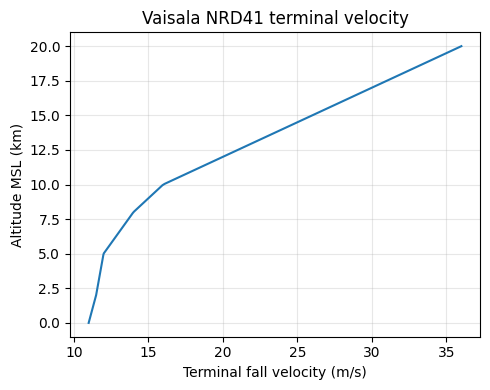

In [2]:
alts_m = np.linspace(0, 20000, 200)
w_mps = [
    float(terminal_velocity_nrd41(a * ureg.meter).m_as('meter / second'))
    for a in alts_m
]
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(w_mps, alts_m / 1000.0, color='C0')
ax.set_xlabel('Terminal fall velocity (m/s)')
ax.set_ylabel('Altitude MSL (km)')
ax.set_title('Vaisala NRD41 terminal velocity')
ax.grid(alpha=0.3)
fig.tight_layout()
_show(fig)

## 2. Aircraft + `FlightLine` — pre-plan release generation

`releases_along_flight_line` works **before** `compute_flight_plan`
runs — useful for interactive design.  When you pass an `aircraft`
but no `groundspeed`, the helper falls back to
`aircraft.cruise_speed_at(altitude)`.  The host aircraft also drives
the envelope checks (`qc_aircraft_envelope_ok`, `qc_segment_allowed`)
that feed into the tri-state `qc_release_ok` aggregate.

In [3]:
aircraft = NASA_P3()
fl_demo = FlightLine.start_length_azimuth(
    lat1=30.0, lon1=-80.0,
    length=370 * ureg.kilometer, az=90.0,
    altitude_msl=20000 * ureg.foot,
    site_name='AR_transect',
)
print(f'Flight line: {fl_demo.length:~.0f} at FL{fl_demo.altitude_msl.m_as("foot")/100:.0f}')
print(f'Aircraft cruise at FL200: {aircraft.cruise_speed_at(fl_demo.altitude_msl):~.0f}')

takeoff = dt.datetime(2024, 1, 15, 18, 0, 0, tzinfo=dt.timezone.utc)
rels = releases_along_flight_line(
    fl_demo,
    sensor=AVAPS_NRD41,
    aircraft=aircraft,                # cruise speed used as groundspeed fallback
    spacing=20 * ureg.nautical_mile,
    takeoff_time=takeoff,
)
print(f'\n{len(rels)} releases generated:')
for r in rels[:3]:
    print(f'  id={r.release_id:2d} t={r.release_time} '
          f'lat={r.waypoint.latitude:7.4f} lon={r.waypoint.longitude:7.4f} '
          f'qc_ok={r.qc_release_ok}')

Flight line: 370000 m at FL200
Aircraft cruise at FL200: 333 kn

10 releases generated:
  id= 0 t=2024-01-15 18:00:00+00:00 lat=30.0000 lon=-80.0000 qc_ok=None
  id= 1 t=2024-01-15 18:03:36.216216+00:00 lat=29.9994 lon=-79.6161 qc_ok=None
  id= 2 t=2024-01-15 18:07:12.432432+00:00 lat=29.9978 lon=-79.2322 qc_ok=None


## 3. Simulate one release under three winds

`simulate_release(release, wind_field=...)` returns a
`DropsondeTrajectory` whose `track` is the per-step descent and whose
`splash_waypoint` is the predicted impact point.

Three physical effects are visible:

- The sonde inherits the aircraft's horizontal velocity at release and
  decays linearly to the local wind over `sensor.deployment_time`
  (5 s by default).  At the NASA P-3 cruise speed (~346 kt at FL200,
  ~178 m/s) the average velocity over those 5 s is ~89 m/s, so the
  still-air splash sits ~440 m east of release — about 65 m below it,
  since the sonde only falls ~65 m before the transient ends.
- The kernel samples wind at the *current* trajectory point at every
  step, so vertical-shear effects appear naturally.  The shear case
  below uses a linear easterly jet that maxes at 30 m/s at FL200 and
  decays to 0 at sea level — the descent-profile curve bends as the
  sonde falls through weaker winds.
- Constant winds, by contrast, produce a straight diagonal in the
  descent-profile plot.


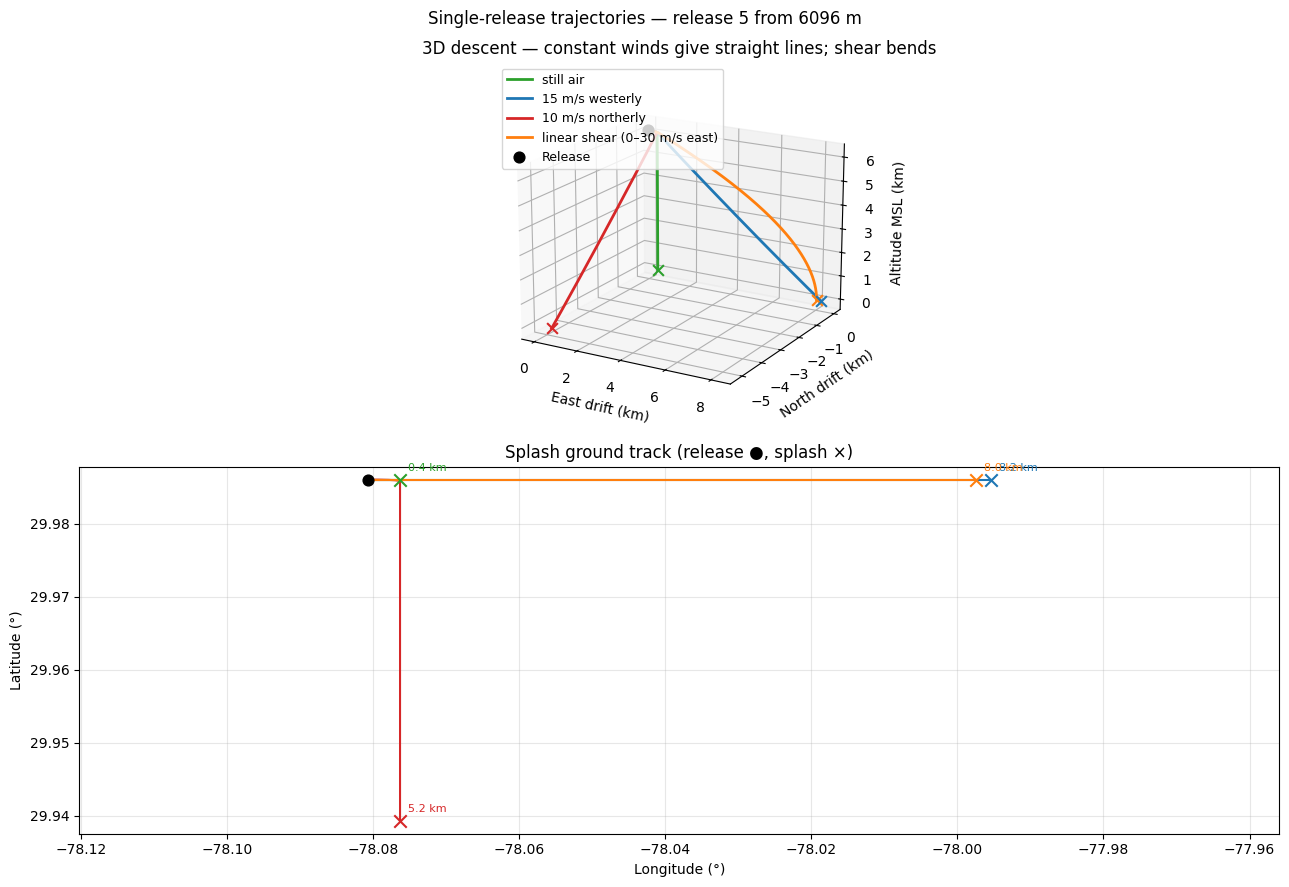

In [4]:
from hyplan.winds import WindField


class LinearShearEasterly(WindField):
    """u-only easterly jet that decays linearly from `u_top` at `z_top`
    down to 0 at sea level.  Time-independent."""
    is_time_dependent = False

    def __init__(self, u_top_mps: float, z_top_m: float):
        self._u_top = u_top_mps
        self._z_top = z_top_m

    def wind_at(self, lat, lon, altitude, time):
        z_m = float(altitude.m_as('meter'))
        frac = max(0.0, min(1.0, z_m / self._z_top))
        u_mps = self._u_top * frac
        return (
            u_mps * ureg.meter / ureg.second,
            0.0 * ureg.meter / ureg.second,
        )


rel = rels[len(rels) // 2]
winds = {
    'still air':              StillAirField(),
    '15 m/s westerly':        ConstantWindField(15 * ureg.meter / ureg.second, wind_from_deg=270.0),
    '10 m/s northerly':       ConstantWindField(10 * ureg.meter / ureg.second, wind_from_deg=0.0),
    'linear shear (0–30 m/s east)': LinearShearEasterly(u_top_mps=30.0, z_top_m=6100.0),
}
trajs = {label: simulate_release(rel, wind_field=w) for label, w in winds.items()}
colors = ['C2', 'C0', 'C3', 'C1']

# Convert each trajectory to (east_km, north_km, altitude_km) relative
# to the release point so all three axes share comparable units.
lat0 = rel.waypoint.latitude
lon0 = rel.waypoint.longitude
m_per_deg_lat = 111_320.0
m_per_deg_lon = m_per_deg_lat * float(np.cos(np.radians(lat0)))


def _xyz_km(traj):
    lats = traj.track['latitude'].to_numpy()
    lons = traj.track['longitude'].to_numpy()
    alts = traj.track['altitude_msl_m'].to_numpy()
    east_km = (lons - lon0) * m_per_deg_lon / 1000.0
    north_km = (lats - lat0) * m_per_deg_lat / 1000.0
    alt_km = alts / 1000.0
    return east_km, north_km, alt_km


fig = plt.figure(figsize=(13, 9))
ax_3d = fig.add_subplot(2, 1, 1, projection='3d')
ax_map = fig.add_subplot(2, 1, 2)

# Top: 3D descent in local east-north-altitude.  Constant winds = straight
# diagonal; the shear case bends because u falls with altitude.
for (label, traj), c in zip(trajs.items(), colors):
    e, n, a = _xyz_km(traj)
    ax_3d.plot(e, n, a, lw=2.0, color=c, label=label)
    ax_3d.scatter([e[-1]], [n[-1]], [a[-1]], marker='x', s=60, color=c)
ax_3d.scatter([0], [0], [rel.waypoint.altitude_msl.m_as('kilometer')],
              color='k', marker='o', s=60, label='Release')
ax_3d.set_xlabel('East drift (km)')
ax_3d.set_ylabel('North drift (km)')
ax_3d.set_zlabel('Altitude MSL (km)')
ax_3d.set_title('3D descent — constant winds give straight lines; shear bends')
ax_3d.view_init(elev=18, azim=-60)
ax_3d.legend(loc='upper left', fontsize=9)

# Bottom: 2D ground track with equal aspect, splash drifts annotated.
ax_map.scatter([rel.waypoint.longitude], [rel.waypoint.latitude],
               color='k', marker='o', s=60, zorder=5)
for (label, traj), c in zip(trajs.items(), colors):
    ax_map.plot(traj.track['longitude'], traj.track['latitude'], lw=1.5, color=c)
    ax_map.scatter([traj.splash_waypoint.longitude], [traj.splash_waypoint.latitude],
                   marker='x', s=80, color=c, zorder=6)
    drift_km = float(traj.drift_distance.m_as('kilometer'))
    ax_map.annotate(
        f'{drift_km:.1f} km',
        xy=(traj.splash_waypoint.longitude, traj.splash_waypoint.latitude),
        xytext=(6, 6), textcoords='offset points', fontsize=8, color=c,
    )
ax_map.set_xlabel('Longitude (°)')
ax_map.set_ylabel('Latitude (°)')
ax_map.set_aspect('equal', adjustable='datalim')
ax_map.set_title('Splash ground track (release ●, splash ×)')
ax_map.grid(alpha=0.3)

fig.suptitle(f'Single-release trajectories — release {rel.release_id} from {rel.waypoint.altitude_msl:~.0f}')
fig.tight_layout()
_show(fig)


## 4. `DropsondePlan.from_flight_plan(...).simulate(...)`

For a real campaign, run `compute_flight_plan(aircraft, [...])` to get
the segment-resolved track — that includes takeoff, climb, transit,
flight lines, descent, and approach with the aircraft's actual climb
rate, fuel burn, and crab-angle kinematics applied.  The dropsonde
plan then gates on segment type (default: `flight_line` + `transit`
only) so we don't try to release inside a turn or during climb.

`simulate()` is functional: the original plan stays untouched and a
new plan with trajectories + post-sim QC is returned.

In [5]:
fl_east  = FlightLine.start_length_azimuth(
    lat1=30.0, lon1=-79.0,
    length=300 * ureg.kilometer, az=90.0,
    altitude_msl=20000 * ureg.foot,
    site_name='East leg',
)
fl_south = FlightLine.start_length_azimuth(
    lat1=30.1, lon1=-75.8,
    length=200 * ureg.kilometer, az=180.0,
    altitude_msl=20000 * ureg.foot,
    site_name='South leg',
)
plan_gdf = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=[fl_east, fl_south],
    takeoff_time=takeoff,
)
print(f'compute_flight_plan returned {len(plan_gdf)} segments:')
print(plan_gdf[['segment_type', 'segment_name', 'distance', 'time_to_segment']].to_string(index=False))

compute_flight_plan returned 3 segments:
segment_type segment_name   distance  time_to_segment
 flight_line     East leg 167.987017        30.267931
     transit    Departure  28.539192         5.142197
 flight_line    South leg 113.991391        20.538989


In [6]:
polygon = shapely.geometry.box(-77.5, 29.5, -76.0, 30.5)
wind = ConstantWindField(15 * ureg.meter / ureg.second, wind_from_deg=270.0)

plan = DropsondePlan.from_flight_plan(
    plan_gdf,
    sensor=AVAPS_NRD41,
    aircraft=aircraft,
    takeoff_time=takeoff,
    spacing=20 * ureg.nautical_mile,
    target_polygon=polygon,
)
print(f'pre-sim:  {len(plan.releases)} releases, {len(plan.trajectories)} trajectories')

plan2 = plan.simulate(wind_field=wind, n_ensemble=10, rng_seed=42)
print(f'post-sim: {len(plan2.releases)} releases, {len(plan2.trajectories)} trajectories')
print(f'plan2 is plan? {plan2 is plan}  (functional simulate)')

summary = plan2.summary()
summary[['release_id', 'n_ensemble',
         'drift_distance_m_mean',
         'splash_ellipse_semi_major_m', 'splash_ellipse_semi_minor_m',
         'fraction_in_polygon']]

pre-sim:  17 releases, 0 trajectories


post-sim: 17 releases, 170 trajectories
plan2 is plan? False  (functional simulate)


,release_id,n_ensemble,drift_distance_m_mean,splash_ellipse_semi_major_m,splash_ellipse_semi_minor_m,fraction_in_polygon
0,0,10,8255.557665,952.882702,390.910108,0.0
1,1,10,8502.950328,867.788817,514.930178,0.0
2,2,10,7968.684970,629.207975,451.084964,0.0
3,3,10,8314.009825,821.811739,690.332783,0.0
4,4,10,8418.308268,1178.265810,835.376743,1.0
5,5,10,8173.703789,928.640480,506.484900,1.0
6,6,10,8430.072084,945.403739,667.073795,1.0
7,7,10,8160.619018,924.716285,500.480905,1.0
8,8,10,8217.527546,1091.808156,629.993635,0.0
9,9,10,8485.417678,1144.952333,408.045902,0.0


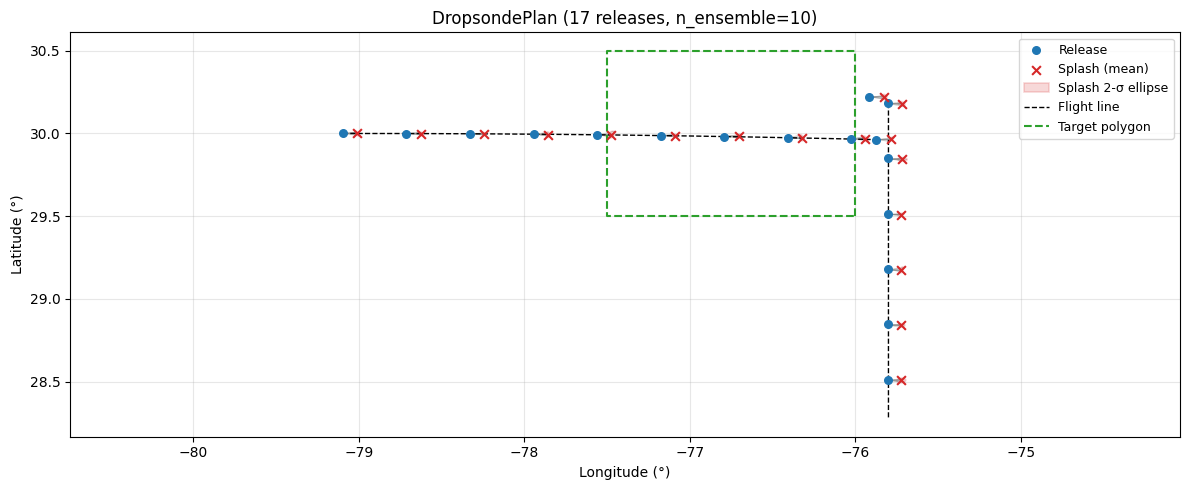

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
plan2.plot(ax=ax)
# Overlay every flight-line geometry from the computed plan.
for _, row in plan_gdf[plan_gdf['segment_type'] == 'flight_line'].iterrows():
    xs, ys = row.geometry.xy
    ax.plot(list(xs), list(ys), 'k--', lw=1.0, zorder=2,
            label='Flight line' if 'Flight line' not in [t.get_label() for t in ax.get_lines()] else None)
px, py = polygon.exterior.xy
ax.plot(px, py, color='C2', lw=1.5, ls='--', label='Target polygon')
ax.set_title(f'DropsondePlan ({len(plan2.releases)} releases, n_ensemble=10)')
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
_show(fig)

## 5. QC lifecycle

Tri-state `qc_release_ok` aggregates three gating flags:
`qc_min_alt_ok`, `qc_aircraft_envelope_ok`, `qc_segment_allowed`.
When `aircraft` is supplied to `from_flight_plan`, the envelope and
segment-type gates become definite booleans; without surface-elevation
info the minimum-AGL gate stays `None`.

`qc_splash_in_target_polygon` is **not** part of `qc_release_ok` — it
is a post-simulation diagnostic populated by `simulate()` against the
ensemble-mean splash position.  Pre-sim it stays `None`.

In [8]:
print('pre-sim QC (qc_release_ok aggregates gates only):')
for r in plan.releases[:6]:
    print(f'  id={r.release_id:2d}  min_alt={r.qc_min_alt_ok}  envelope={r.qc_aircraft_envelope_ok}  '
          f'segment={r.qc_segment_allowed}  -> release_ok={r.qc_release_ok}  '
          f'(polygon={r.qc_splash_in_target_polygon})')
print('\npost-sim QC (polygon now populated):')
for r in plan2.releases[:6]:
    print(f'  id={r.release_id:2d}  release_ok={r.qc_release_ok}  '
          f'splash_in_polygon={r.qc_splash_in_target_polygon}')

pre-sim QC (qc_release_ok aggregates gates only):
  id= 0  min_alt=None  envelope=True  segment=True  -> release_ok=None  (polygon=None)
  id= 1  min_alt=None  envelope=True  segment=True  -> release_ok=None  (polygon=None)
  id= 2  min_alt=None  envelope=True  segment=True  -> release_ok=None  (polygon=None)
  id= 3  min_alt=None  envelope=True  segment=True  -> release_ok=None  (polygon=None)
  id= 4  min_alt=None  envelope=True  segment=True  -> release_ok=None  (polygon=None)
  id= 5  min_alt=None  envelope=True  segment=True  -> release_ok=None  (polygon=None)

post-sim QC (polygon now populated):
  id= 0  release_ok=None  splash_in_polygon=False
  id= 1  release_ok=None  splash_in_polygon=False
  id= 2  release_ok=None  splash_in_polygon=False
  id= 3  release_ok=None  splash_in_polygon=False
  id= 4  release_ok=None  splash_in_polygon=True
  id= 5  release_ok=None  splash_in_polygon=True


## 6. Inverse Lagrangian targeting

`solve_release_for_target` finds the release time along the aircraft
trajectory whose simulated splash lands closest to a chosen target.
The constraint is the aircraft trajectory itself — the solver does
not search 'release anywhere'.  Coarse scan via
`FlightPlanTrack.iter_samples`, then in-tree golden-section refinement
(no SciPy dependency).

Plans built via `from_pattern` (or from bare releases) deliberately
carry `flight_track=None` and raise here — the solver needs the
continuous aircraft trajectory.

feasible:       False
miss_distance:  12321 m
release time:   2024-01-15 18:16:58.784938+00:00
release point:  (29.9889, -77.2873)
splash point:   (29.9889, -77.2019)


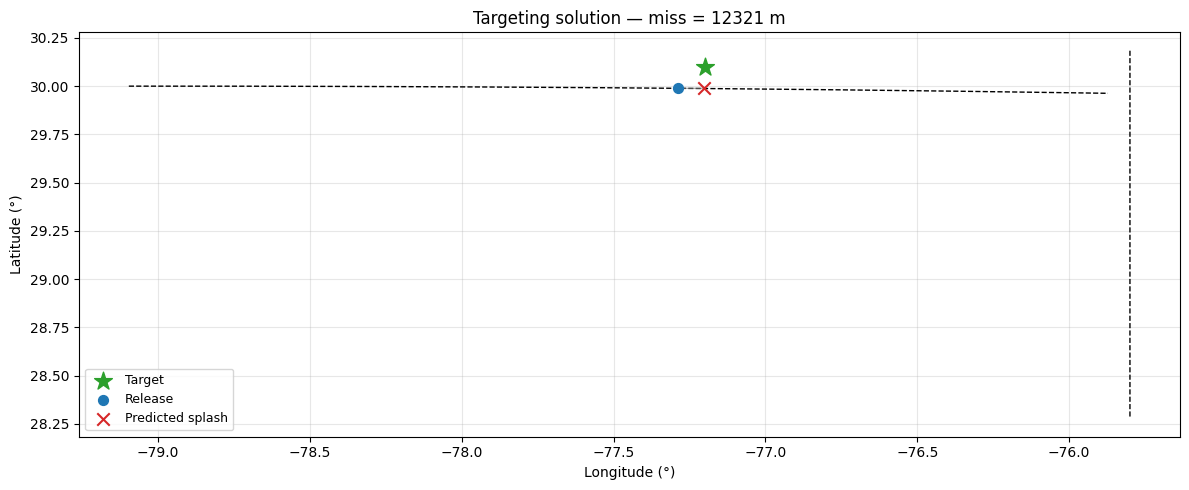

In [9]:
target = Waypoint(latitude=30.1, longitude=-77.2, heading=0.0, name='Target')
solution = solve_release_for_target(
    target=target,
    flight_plan=plan2,        # DropsondePlan carries its flight_track
    sensor=AVAPS_NRD41,
    aircraft=aircraft,
    takeoff_time=takeoff,
    wind_field=wind,
    tolerance=500 * ureg.meter,
    coarse_step=10 * ureg.second,
)
print(f'feasible:       {solution.feasible}')
print(f'miss_distance:  {solution.miss_distance:~.0f}')
print(f'release time:   {solution.release.release_time}')
print(f'release point:  ({solution.release.waypoint.latitude:.4f}, {solution.release.waypoint.longitude:.4f})')
print(f'splash point:   ({solution.trajectory.splash_waypoint.latitude:.4f}, {solution.trajectory.splash_waypoint.longitude:.4f})')

fig, ax = plt.subplots(figsize=(12, 5))
for _, row in plan_gdf[plan_gdf['segment_type'] == 'flight_line'].iterrows():
    xs, ys = row.geometry.xy
    ax.plot(list(xs), list(ys), 'k--', lw=1.0)
ax.scatter([target.longitude], [target.latitude],
           color='C2', marker='*', s=180, zorder=5, label='Target')
ax.scatter([solution.release.waypoint.longitude],
           [solution.release.waypoint.latitude],
           color='C0', marker='o', s=50, zorder=5, label='Release')
ax.scatter([solution.trajectory.splash_waypoint.longitude],
           [solution.trajectory.splash_waypoint.latitude],
           color='C3', marker='x', s=80, zorder=5, label='Predicted splash')
ax.plot(solution.trajectory.track['longitude'],
        solution.trajectory.track['latitude'],
        color='gray', lw=0.8, alpha=0.7)
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title(f'Targeting solution — miss = {float(solution.miss_distance.m_as("meter")):.0f} m')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
_show(fig)

## 7. `Pattern` integration — racetrack survey

`DropsondePlan.from_pattern` works directly off HyPlan's pattern
generators.  Spacing resets per line; line-to-line transit is not
modelled (a bare `Pattern` has no transit solution — use
`from_flight_plan(compute_flight_plan(...))` for authoritative
multi-line timing).  Each release carries the originating line as its
`source` and `pattern.pattern_id` as `source_pattern_id`.

Pattern "AR survey" has 3 lines


15 releases, 120 trajectories
flight_track set?  False  (False => targeting solver will refuse)


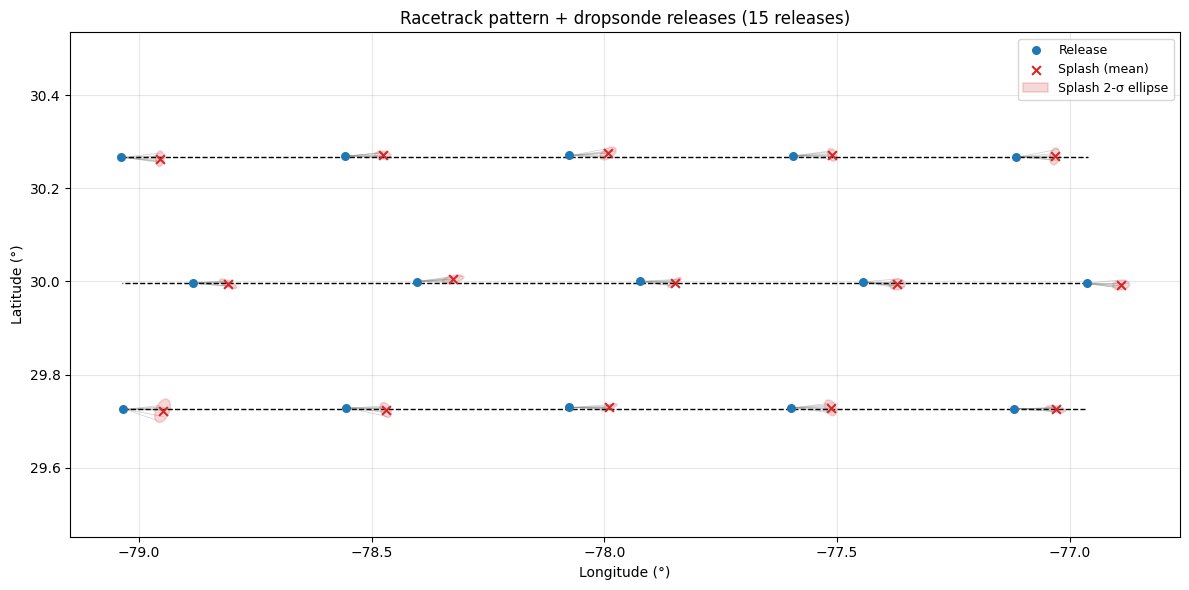

In [10]:
pat = racetrack(
    center=(30.0, -78.0),
    heading=90.0,
    altitude=20000 * ureg.foot,
    leg_length=200 * ureg.kilometer,
    n_legs=3,
    offset=30 * ureg.kilometer,
    name='AR survey',
)
print(f'Pattern "{pat.name}" has {len(pat.lines)} lines')

pat_plan = DropsondePlan.from_pattern(
    pat,
    sensor=AVAPS_NRD41,
    aircraft=aircraft,
    spacing=25 * ureg.nautical_mile,
)
pat_plan_sim = pat_plan.simulate(wind_field=wind, n_ensemble=8, rng_seed=7)
print(f'{len(pat_plan_sim.releases)} releases, '
      f'{len(pat_plan_sim.trajectories)} trajectories')
print(f'flight_track set?  {pat_plan_sim.flight_track is not None}  '
      f'(False => targeting solver will refuse)')

fig, ax = plt.subplots(figsize=(12, 6))
pat_plan_sim.plot(ax=ax)
for line in pat.lines.values():
    xs, ys = line.geometry.xy
    ax.plot(list(xs), list(ys), 'k--', lw=1.0)
ax.set_title(f'Racetrack pattern + dropsonde releases ({len(pat_plan_sim.releases)} releases)')
fig.tight_layout()
_show(fig)

## 8. Real winds — MERRA-2 reanalysis (cached)

Sections 1–7 use analytic winds.  This section runs the same code
path against a real MERRA-2 reanalysis slab over the western North
Atlantic on 2024-01-15 18Z.  The slab is pre-fetched and committed to
`notebooks/exampledata/merra2_atlantic_2024-01-15.nc`, so the notebook
runs offline and auth-free.

Re-fetch with `MERRA2WindField.for_plan(plan_gdf, time_start=...).to_netcdf(path)`
and valid Earthdata credentials.

Loaded MERRA-2 slab from exampledata/merra2_atlantic_2024-01-15.nc


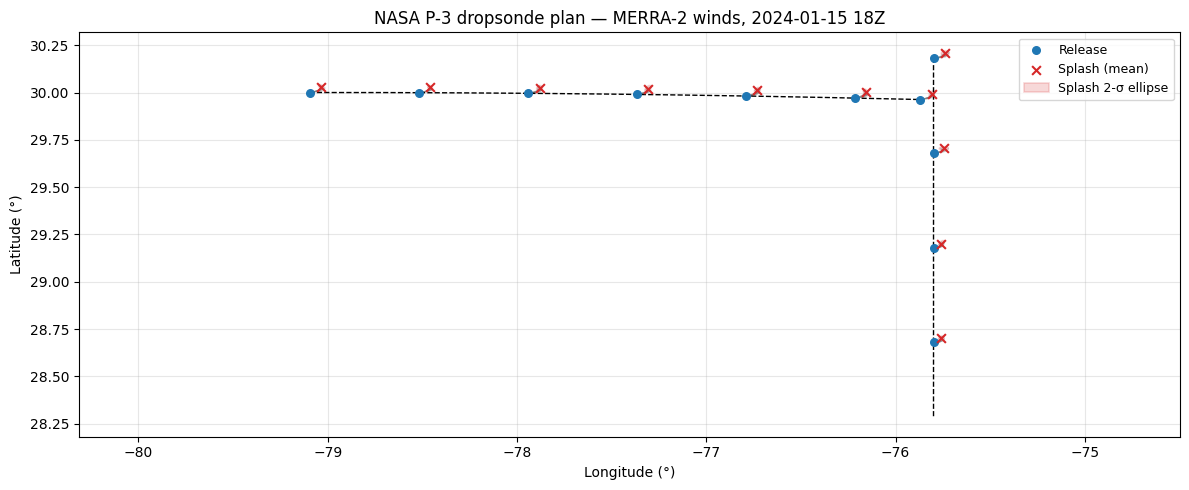

In [11]:
cache_path = Path('exampledata') / 'merra2_atlantic_2024-01-15.nc'
if not cache_path.exists():
    cache_path = Path('notebooks') / cache_path  # nbconvert from repo root
wind_merra2 = MERRA2WindField.from_netcdf(str(cache_path))
print(f'Loaded MERRA-2 slab from {cache_path}')

real_plan = DropsondePlan.from_flight_plan(
    plan_gdf,
    sensor=AVAPS_NRD41,
    aircraft=aircraft,
    takeoff_time=takeoff,
    spacing=30 * ureg.nautical_mile,
)
real_plan_sim = real_plan.simulate(
    wind_field=wind_merra2, n_ensemble=15, rng_seed=42,
)

fig, ax = plt.subplots(figsize=(12, 5))
real_plan_sim.plot(ax=ax)
for _, row in plan_gdf[plan_gdf['segment_type'] == 'flight_line'].iterrows():
    xs, ys = row.geometry.xy
    ax.plot(list(xs), list(ys), 'k--', lw=1.0)
ax.set_title('NASA P-3 dropsonde plan — MERRA-2 winds, 2024-01-15 18Z')
fig.tight_layout()
_show(fig)

## 9. Adapting to a different sonde — Sippican AXCTD

The `DropsondeSystem` class is parameterised by a `descent_rate_model`
callable plus a handful of operational kwargs, so adapting to a
different sonde is a one-line constructor.  The pre-configured
`AXCTD` reference is the Lockheed-Martin Sippican AXCTD —
**air-phase only**: the kernel terminates at splash, and the
water-column descent through the ocean is out of scope.  Same release
manifest, same trajectory simulator, same inverse-targeting solver;
just a slower terminal velocity and a smaller deployment chute.


AVAPS NRD41:  fall 522 s, drift 8234.3 m
Sippican AXCTD: fall 562 s, drift 8679.9 m


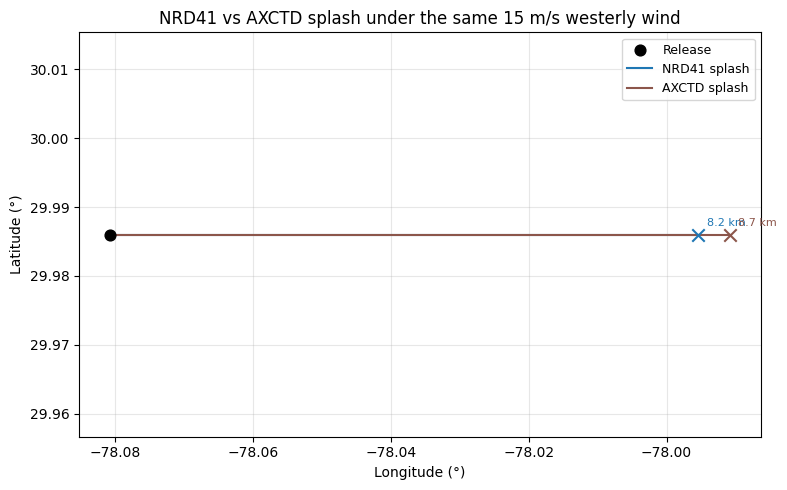

In [12]:
from hyplan.instruments.dropsondes import AXCTD

# Same release (same lat/lon/altitude/time/aircraft) — only the sensor
# differs.  Use `dataclasses.replace` because DropsondeRelease is frozen.
import dataclasses
rel_axctd = dataclasses.replace(rel, sensor=AXCTD)

wind_demo = ConstantWindField(15 * ureg.meter / ureg.second, wind_from_deg=270.0)
traj_nrd41 = simulate_release(rel,       wind_field=wind_demo)
traj_axctd = simulate_release(rel_axctd, wind_field=wind_demo)

print(f'AVAPS NRD41:  fall {traj_nrd41.time_to_surface:~.0f}, '
      f'drift {traj_nrd41.drift_distance:~.1f}')
print(f'Sippican AXCTD: fall {traj_axctd.time_to_surface:~.0f}, '
      f'drift {traj_axctd.drift_distance:~.1f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter([rel.waypoint.longitude], [rel.waypoint.latitude],
           color='k', marker='o', s=60, zorder=5, label='Release')
for traj, label, c in [(traj_nrd41, 'NRD41 splash', 'C0'),
                       (traj_axctd, 'AXCTD splash', 'C5')]:
    ax.plot(traj.track['longitude'], traj.track['latitude'], lw=1.5, color=c, label=label)
    ax.scatter([traj.splash_waypoint.longitude], [traj.splash_waypoint.latitude],
               marker='x', s=80, color=c, zorder=6)
    drift_km = float(traj.drift_distance.m_as('kilometer'))
    ax.annotate(f'{drift_km:.1f} km',
                xy=(traj.splash_waypoint.longitude, traj.splash_waypoint.latitude),
                xytext=(6, 6), textcoords='offset points', fontsize=8, color=c)
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_aspect('equal', adjustable='datalim')
ax.set_title('NRD41 vs AXCTD splash under the same 15 m/s westerly wind')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
_show(fig)
